<a href="https://colab.research.google.com/github/peremartra/optipfair/blob/main/examples/knowledge_distillation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# OptiPFair Notebook Series - Example: Knowledge Distillation
![optiPfair Logo](https://github.com/peremartra/optipfair/blob/main/images/optiPfair.png?raw=true)
This notebook demonstrates how to use [OptiPFair](https://github.com/peremartra/optipfair) to recover performance after depth pruning using knowledge distillation.  
It follows the full recommended workflow with public APIs only: load a teacher model, create a depth-pruned student, distill knowledge, and visualize training curves.

The benchmark stage with lm_eval is intentionally excluded in this example.

##Recommended Environment

- **Platform**: [Google Colab](https://colab.research.google.com)  
- **Hardware**: GPU A100.
- **Dependencies**: Installed in Section 0

##by Pere Martra.

- [LinkedIn](https://www.linkedin.com/in/pere-martra)  
- [GitHub](https://github.com/peremartra)  
- [X / Twitter](https://x.com/peremartra)

---

> If you find this useful, please ⭐ the [repository](https://github.com/peremartra/optipfair) and share it!

---
If you want your favorite LLM to create code with optiPfair, you just need to provide it with the file: [**optipfair_llm_reference_manual.txt**](https://github.com/peremartra/optipfair/blob/main/optipfair_llm_reference_manual.txt), which contains all the necessary information for the LLM to become an expert in using the library.

# Knowledge Distillation Example

This notebook demonstrates how to recover a depth-pruned model with OptiPFair knowledge distillation.
We follow the recommended sequence for post-pruning recovery:
1. Load a teacher model
2. Prepare a small recovery dataset
3. Build a depth-pruned student with OptiPFair
4. Recover performance with knowledge distillation using `opf.distill_model()`
5. Plot training losses from `stats['loss_history']`

## 0. Environment and Dependencies\n
First, install the required libraries and define the base configuration.

In [1]:
!pip install git+https://github.com/peremartra/optipfair.git

  Cloning https://github.com/peremartra/optipfair.git to /tmp/pip-req-build-hrq0acl0
  Running command git clone --filter=blob:none --quiet https://github.com/peremartra/optipfair.git /tmp/pip-req-build-hrq0acl0
  Resolved https://github.com/peremartra/optipfair.git to commit 268258707ea63ba0a742b0206d547d0107905839
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for optipfair: filename=optipfair-0.3.0-py3-none-any.whl size=64358 sha256=cac9ea90129457b56a25ea55db7d8e7fb0cccb84bdff112648e598ad57fb0c52
  Stored in directory: /tmp/pip-ephem-wheel-cache-kj2y5c_v/wheels/34/ee/95/45c0e77756d6cde346debec33bab0826fe994bc1baeeda4f31
Successfully built optipfair


In [2]:
!pip install -q transformers==5.4.0
!pip install -q datasets tqdm matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 91.9 MB/s eta 0:00:00


In [3]:
RECOVERY_SAMPLES = 200   # Use a small number for the example\n
EPOCHS = 3
LEARNING_RATE = 4e-5
BATCH_SIZE = 4
MAX_LENGTH = 512
LAYERS_TO_REMOVE_COUNT = 2

In [4]:
import torch
from copy import deepcopy
from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import load_dataset, Dataset
from torch.utils.data import TensorDataset, DataLoader, random_split
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import optipfair as opf

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 1. Load Teacher Model
Load the teacher model in evaluation mode and freeze all its parameters.

The teacher is only used as a supervision signal during distillation.

In [ ]:
MODEL_NAME = "Qwen/Qwen3.5-0.8B-Base"   # or "google/gemma-3-270m" for a smaller option\n

print(f"Loading Teacher model: {MODEL_NAME}")
teacher_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map="auto" if torch.cuda.is_available() else None
)

teacher_model.eval()
for param in teacher_model.parameters():
    param.requires_grad = False

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

n_teacher_layers = teacher_model.config.num_hidden_layers
print(f"Teacher: {n_teacher_layers} layers, {teacher_model.num_parameters():,} params")

## 2. Prepare Training Dataset
Adapted from NB03: load Cosmopedia in streaming mode, tokenize text, and create an 80/20 train/validation split.

In [ ]:
print("Loading Cosmopedia dataset...")
dataset_name = "HuggingFaceTB/cosmopedia"
subsets = ["stories", "wikihow", "openstax", "web_samples_v1"]
samples_per_subset = int(RECOVERY_SAMPLES / len(subsets))\

all_samples = []
for subset in subsets:
    print(f"  Loading {subset}...")
    subset_data = load_dataset(dataset_name, subset, split="train", streaming=True)
    subset_samples = list(subset_data.take(samples_per_subset))
    all_samples.extend(subset_samples)
    print(f"    Collected {len(subset_samples):,} samples")

distillation_dataset = Dataset.from_dict({"text": [s["text"] for s in all_samples]})
print(f"Total samples: {len(distillation_dataset):,}")

In [ ]:
print("Tokenizing...")
texts = [item["text"] for item in distillation_dataset]
tokenized_data = []
for i in tqdm(range(0, len(texts), 100), desc="Tokenizing"):
    batch = tokenizer(
        texts[i:i + 100],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
        return_tensors="pt"
    )
    tokenized_data.append(batch)

input_ids = torch.cat([b["input_ids"] for b in tokenized_data], dim=0)
attention_mask = torch.cat([b["attention_mask"] for b in tokenized_data], dim=0)
full_dataset = TensorDataset(input_ids, attention_mask)

generator = torch.Generator().manual_seed(42)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(
    full_dataset, [train_size, val_size], generator=generator
)

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

print(f"Train: {len(train_dataset):,} samples ({len(train_dataloader):,} batches)")
print(f"Val:   {len(val_dataset):,} samples")

## 3. Create Pruned Student Model\n
Analyze layer importance with calibration data, remove the least important layers, and prepare the student for training.

In [8]:
print("Analyzing layer importance...")
student_model = deepcopy(teacher_model)
importance_scores = opf.analyze_layer_importance(
    student_model,
    train_dataloader,
    show_progress=True
)

print("\nLayer importance scores (lower = less important):")
for layer_idx, score in sorted(importance_scores.items()):
    print(f"  Layer {layer_idx:2d}: {score:.6f}")

Analyzing layer importance...


Processing batches: 100%|██████████| 40/40 [00:12<00:00,  3.13it/s]


Layer importance scores (lower = less important):
  Layer  0: 0.837903
  Layer  1: 0.168945
  Layer  2: 0.200293
  Layer  3: 0.174414
  Layer  4: 0.139453
  Layer  5: 0.122559
  Layer  6: 0.136621
  Layer  7: 0.116309
  Layer  8: 0.073828
  Layer  9: 0.061816
  Layer 10: 0.076172
  Layer 11: 0.096484
  Layer 12: 0.076953
  Layer 13: 0.083496
  Layer 14: 0.118164
  Layer 15: 0.144824
  Layer 16: 0.093066
  Layer 17: 0.072656
  Layer 18: 0.080469
  Layer 19: 0.079102
  Layer 20: 0.059180
  Layer 21: 0.045508
  Layer 22: 0.072168
  Layer 23: 0.277344


In [9]:
LAYERS_TO_REMOVE = sorted(
    importance_scores.keys(),
    key=lambda x: importance_scores[x]
)[:LAYERS_TO_REMOVE_COUNT]

print(f"Layers selected for removal: {LAYERS_TO_REMOVE}")

Layers selected for removal: [21, 20]


In [10]:
student_model = opf.prune_model_depth(
    model=student_model,
    layer_indices=LAYERS_TO_REMOVE,
    show_progress=True
)

for param in student_model.parameters():
    param.requires_grad = True

n_student_layers = student_model.config.num_hidden_layers
print(f"\nTeacher layers: {n_teacher_layers}")
print(f"Student layers: {n_student_layers} (removed {LAYERS_TO_REMOVE})")
print(f"Student params: {student_model.num_parameters():,}")

Removing layers: 100%|██████████| 24/24 [00:00<00:00, 259441.48it/s]


Teacher layers: 24
Student layers: 22 (removed [21, 20])
Student params: 709,282,304


## 4. Knowledge Distillation with OptiPFair
Run labels-only distillation (hard labels + skew KLD) using the OptiPFair public API.

Feature alignment is disabled in this configuration (gamma=0, delta=0).

In [ ]:
student_to_train = deepcopy(student_model)

trained_student, stats = opf.distill_model(
    student_model=student_to_train,
    teacher_model=teacher_model,
    dataloader=train_dataloader,
    alpha=0.6,
    beta=0.4,
    gamma=0.0,
    delta=0.0,
    temperature=2.0,
    skew_alpha=0.4,
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    accumulation_steps=4,
    show_progress=True,
    return_stats=True,
)

print("\nTraining complete")
print(f"  Total time:        {stats['total_time_seconds']:.1f}s ({stats['total_time_seconds'] / 60:.1f} min)")
print(f"  Avg time/epoch:    {stats['avg_time_per_epoch']:.1f}s")
print(f"  Final total loss:  {stats['loss_history']['total'][-1]:.4f}")
print(f"  Final task loss:   {stats['loss_history']['task'][-1]:.4f}")
print(f"  Final logits loss: {stats['loss_history']['logits'][-1]:.4f}")

## 5. Visualize Training Loss Curves
Plot total, task, and logits losses using the stats dictionary returned by distill_model.

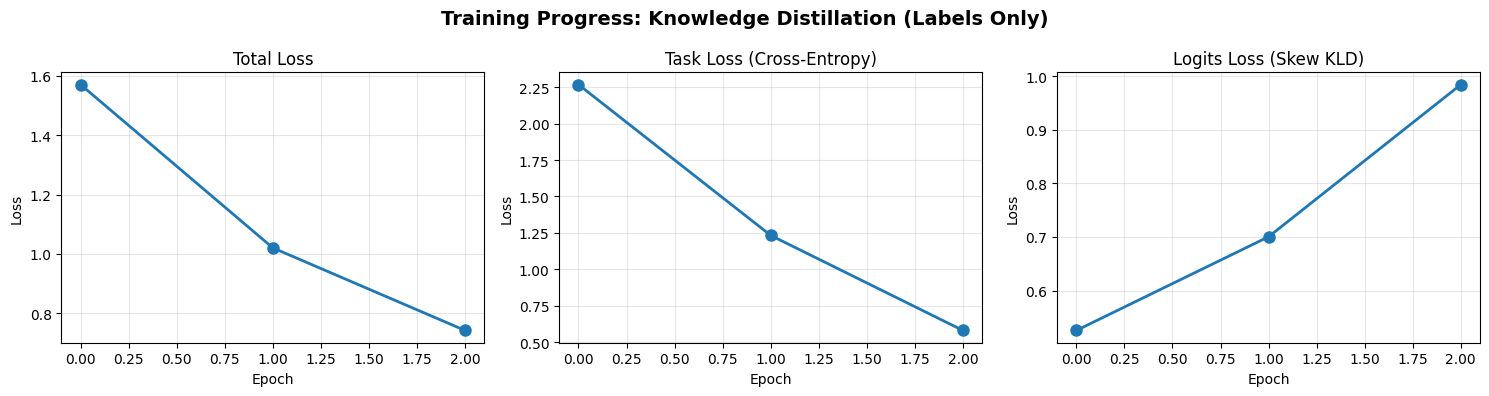

Plot saved to kd_training_curves.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

loss_keys = [
    ("total",  "Total Loss"),
    ("task",   "Task Loss (Cross-Entropy)"),
    ("logits", "Logits Loss (Skew KLD)"),
]

for idx, (key, title) in enumerate(loss_keys):
    axes[idx].plot(
        stats['loss_history'][key],
        marker='o', linewidth=2, markersize=8
    )
    axes[idx].set_title(title, fontsize=12)
    axes[idx].set_xlabel('Epoch')
    axes[idx].set_ylabel('Loss')
    axes[idx].grid(True, alpha=0.3)

plt.suptitle(
    'Training Progress: Knowledge Distillation (Labels Only)',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig('kd_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved to kd_training_curves.png")

## 6. Save Student to Hugging Face (Private) + Clear Memory

We push the trained student to a private HF repository, then free GPU memory.
The teacher remains in memory — we need it for the performance comparison in Section 8.

This step also serves as an **end-to-end validation**: the benchmarks in Section 7 will run
against the model downloaded from HF, confirming that save + load works correctly.

In [ ]:
import gc

# --- Configure your HF repo name ---
HF_MODEL_NAME = "oopere/qwen3-5-student"  # <-- change to your HF username

# 1. Push trained student (private)
print(f"Pushing student to HF: {HF_MODEL_NAME} (private)...")
trained_student.push_to_hub(HF_MODEL_NAME, private=True)
tokenizer.push_to_hub(HF_MODEL_NAME)
print("  ✓ Student uploaded successfully")

# 2. Delete student from memory — teacher stays
del trained_student, student_model, student_to_train
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()
print("  ✓ Student removed from GPU memory (teacher still loaded)")

# Verify teacher is still in memory
print(f"  Teacher layers in memory: {teacher_model.config.num_hidden_layers}")
if torch.cuda.is_available():
    used_gb = torch.cuda.memory_allocated() / 1e9
    print(f"  GPU memory used: {used_gb:.2f} GB")

## 7. Load Student from HF + Benchmarks

Download the student from HF and evaluate it on 5 standard benchmarks using `lm-eval`.
Teacher scores are hardcoded from a reference run on the same GPU environment
(Qwen3.5-0.8B-Base, A100 40GB, full dataset).

**Why download instead of using the model already in memory?**
This confirms the full serialization pipeline (prune → distill → save → load) works
end-to-end, exactly as a downstream user would experience it.

In [14]:
!pip install -q lm-eval langdetect
!wget -q https://raw.githubusercontent.com/peremartra/Rearchitecting-LLMs/main/utils.py

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 kB 6.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 70.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 115.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.1/91.1 kB 11.9 MB/s eta 0:00:00


In [ ]:
!pip install -q codecarbon
from utils import model_evaluation, clear_gpu_cache
LIMIT_BENCHMARK=400

# Teacher reference scores (Qwen3.5-0.8B-Base, full benchmark run)
TEACHER_SCORES = {
    'arc_easy':       67.5,
    'winogrande':     59.4,
    'hellaswag':      54.9,
    'lambada_openai': 50.9,
    'piqa':           71.5,
}
BENCHMARK_TASKS = list(TEACHER_SCORES.keys())

# Load student from HF
print(f"Loading student from HF: {HF_MODEL_NAME}...")
student_eval = AutoModelForCausalLM.from_pretrained(
    HF_MODEL_NAME,
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map="auto" if torch.cuda.is_available() else None
)
student_eval.eval()
n_student_layers_eval = student_eval.config.num_hidden_layers
print(f"  ✓ Student loaded: {n_student_layers_eval} layers, {student_eval.num_parameters():,} params")

# Run benchmarks
print("\nRunning benchmarks on student (this takes ~10-20 min)...")
student_bench_raw = model_evaluation(
    student_eval, tokenizer, BENCHMARK_TASKS, limit=LIMIT_BENCHMARK, device=str(device), batch_size=8
)

# Extract accuracy scores (lm-eval returns nested dicts)
def extract_acc(results, task):
    r = results.get(task, {})
    for k in ('accuracy', 'acc_norm', 'acc'):  # priority order
        if k in r:
            return float(r[k]) * 100
    return 0.0

student_scores = {t: extract_acc(student_bench_raw, t) for t in BENCHMARK_TASKS}

print("\nBenchmark results:")
print(f"{'Task':<20} {'Teacher':>10} {'Student':>10} {'Retention':>12}")
print("-" * 55)
for task in BENCHMARK_TASKS:
    t = TEACHER_SCORES[task]
    s = student_scores[task]
    ret = (s / t * 100) if t > 0 else 0
    print(f"{task:<20} {t:>9.1f}% {s:>9.1f}% {ret:>10.1f}%")

avg_teacher = sum(TEACHER_SCORES.values()) / len(TEACHER_SCORES)
avg_student = sum(student_scores.values()) / len(student_scores)
cap_retention = avg_student / avg_teacher * 100
print(f"{'AVERAGE':<20} {avg_teacher:>9.1f}% {avg_student:>9.1f}% {cap_retention:>10.1f}%")

## 8. Retention Chart

Visual summary of PPL retention, capabilities retention, and overall retention
for Teacher, Pruned (no KD), and Trained Student.

In [ ]:
import numpy as np

# ---- PPL scores ----
# Fill these from the distillation stats or hardcode after a run
teacher_ppl = None   # e.g. 7.34 — set manually if already measured
pruned_ppl  = None   # ppl of the pruned-only (no KD) student
student_ppl = None   # ppl after KD training

# If you have them from stats, uncomment:
# from utils import evaluate_metrics
# val_dataloader = DataLoader(val_dataset, batch_size=8)
# teacher_ppl = evaluate_metrics(teacher_model, val_dataloader, device)['perplexity']
# student_ppl = evaluate_metrics(student_eval, val_dataloader, device)['perplexity']

if teacher_ppl is None or student_ppl is None:
    print("⚠  PPL values not set — retention chart will use benchmark scores only.")
    ppl_retention = {'teacher': 100.0, 'pruned': None, 'trained': None}
else:
    ppl_retention = {
        'teacher': 100.0,
        'pruned':  (teacher_ppl / pruned_ppl * 100) if pruned_ppl else None,
        'trained': (teacher_ppl / student_ppl * 100),
    }

# Capabilities retention per model
# For pruned (no KD) we don't run benchmarks — leave as None or set manually
pruned_scores_avg = None  # set manually if you measured it

cap_ret_teacher = 100.0
cap_ret_student = avg_student / avg_teacher * 100
cap_ret_pruned  = (pruned_scores_avg / avg_teacher * 100) if pruned_scores_avg else None

# Build chart data (skip pruned bar if no data)
models     = ['Teacher', 'Student (KD)']
cap_vals   = [cap_ret_teacher, cap_ret_student]

if ppl_retention['trained'] is not None:
    ppl_vals = [100.0, ppl_retention['trained']]
    overall  = [100.0, (ppl_retention['trained'] + cap_ret_student) / 2]
    metrics  = {'PPL Retention %': ppl_vals,
                'Capabilities Retention %': cap_vals,
                'Overall Retention %': overall}
else:
    metrics = {'Capabilities Retention %': cap_vals}

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(models))
width = 0.25
colors = ['#2e86c1', '#e67e22', '#16a085']
for i, (label, vals) in enumerate(metrics.items()):
    bars = ax.bar(x + (i - len(metrics)//2) * width, vals, width,
                 label=label, color=colors[i], edgecolor='black', linewidth=0.5)
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.1f}',
                    xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', va='bottom', fontsize=9)

ax.axhline(y=100, color='#2ecc71', linestyle='--', linewidth=2, alpha=0.7,
           label='Teacher Baseline (100%)', zorder=0)
ax.set_ylabel('Score / %', fontsize=12)
ax.set_title('Retention vs Teacher Baseline', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend(loc='lower right', fontsize=10)
ax.set_ylim(0, 115)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('retention_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Capabilities Retention: {cap_ret_student:.1f}%")

## 9. Performance Metrics (VRAM + Tokens/sec)

Measure memory footprint and throughput for both teacher and student.
We use `measure_memory_allocation` (static VRAM + dynamic delta from KV cache)
and `measure_detailed_performance` (tokens per second) from `utils.py`.

The teacher is still in memory from Section 1; the student was loaded in Section 7.

In [17]:
from utils import measure_memory_allocation, measure_detailed_performance
from torch.utils.data import DataLoader, TensorDataset

# Fixed prompt for VRAM measurement
PERF_PROMPT = (
    "The transformer architecture revolutionized natural language processing by introducing"
    " the attention mechanism, which allows the model to focus on relevant parts of the input."
)

# --- VRAM measurement ---
print("Measuring VRAM (teacher)...")
teacher_vram = measure_memory_allocation(
    teacher_model, tokenizer, PERF_PROMPT, max_new_tokens=50
)
print("Measuring VRAM (student)...")
student_vram = measure_memory_allocation(
    student_eval, tokenizer, PERF_PROMPT, max_new_tokens=50
)

# --- Build a small ad-hoc DataLoader for TPS measurement ---
PERF_SENTENCES = [
    "The capital of France is",
    "Neural networks learn representations by",
    "The theory of relativity states that",
    "Language models are trained on",
    "Depth pruning reduces the number of layers by",
    "Knowledge distillation transfers information from",
    "The attention mechanism allows transformers to",
    "Gradient descent minimizes the loss function by",
    "The perplexity of a language model measures how",
    "Quantization reduces model size by representing weights in",
]

perf_enc = tokenizer(
    PERF_SENTENCES,
    padding=True, truncation=True, max_length=64, return_tensors='pt'
)
perf_dataset = TensorDataset(perf_enc['input_ids'], perf_enc['attention_mask'])
perf_loader  = DataLoader(perf_dataset, batch_size=2)

# Wrap loader to produce dict batches (as measure_detailed_performance expects)
class DictLoader:
    def __init__(self, dl): self.dl = dl
    def __iter__(self):
        for ids, mask in self.dl:
            yield {'input_ids': ids, 'attention_mask': mask}
    def __len__(self): return len(self.dl)

perf_dict_loader = DictLoader(perf_loader)

# --- TPS measurement ---
print("Measuring tokens/sec (teacher)...")
teacher_perf = measure_detailed_performance(
    teacher_model, tokenizer, perf_dict_loader,
    num_runs=3, max_new_tokens=50, max_samples=10
)
print("Measuring tokens/sec (student)...")
student_perf = measure_detailed_performance(
    student_eval, tokenizer, perf_dict_loader,
    num_runs=3, max_new_tokens=50, max_samples=10
)

Measuring VRAM (teacher)...
Measuring VRAM (student)...


A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


Measuring tokens/sec (teacher)...
🚀 Optimization active: Using Mixed Precision (torch.bfloat16) if available.
Measuring performance on 5 batches (Total samples: 10, 3 runs each)...
   🔥 Performing GPU Warm-up...


A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
Performance test:   0%|          | 0/5 [00:00<?, ?it/s]A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
Performance test:  20%|██        | 1/5 [00:08<00:34,  8.60s/it]A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only ar

Measuring tokens/sec (student)...
🚀 Optimization active: Using Mixed Precision (torch.bfloat16) if available.
Measuring performance on 5 batches (Total samples: 10, 3 runs each)...
   🔥 Performing GPU Warm-up...


A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
Performance test:   0%|          | 0/5 [00:00<?, ?it/s]A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
Performance test:  20%|██        | 1/5 [00:00<00:02,  1.65it/s]A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only ar

## 10. Summary Table

Full comparison: Teacher vs Student across quality, capability, and efficiency metrics.

In [18]:
param_reduction = (
    (teacher_model.num_parameters() - student_eval.num_parameters())
    / teacher_model.num_parameters() * 100
)

rows = [
    ('Layers',           f"{teacher_model.config.num_hidden_layers}",       f"{student_eval.config.num_hidden_layers}"),
    ('Parameters',       f"{teacher_model.num_parameters()/1e6:.0f}M",     f"{student_eval.num_parameters()/1e6:.0f}M"),
    ('Param Reduction',  '—',                                               f"{param_reduction:.1f}%"),
]

# Benchmarks
for task in BENCHMARK_TASKS:
    rows.append((task.replace('_', ' ').title(),
                 f"{TEACHER_SCORES[task]:.1f}%",
                 f"{student_scores[task]:.1f}%"))

rows.append(('Avg Benchmark',
             f"{avg_teacher:.1f}%",
             f"{avg_student:.1f}% ({cap_ret_student:.1f}% retained)"))

# VRAM
rows.append(('Static VRAM',
             f"{teacher_vram['static_vram_mb']:.0f} MB",
             f"{student_vram['static_vram_mb']:.0f} MB"))
rows.append(('Dynamic VRAM (KV cache delta)',
             f"{teacher_vram['dynamic_delta_mb']:.0f} MB",
             f"{student_vram['dynamic_delta_mb']:.0f} MB"))

# TPS
rows.append(('Throughput (tok/s)',
             f"{teacher_perf['throughput_tokens_per_sec']:.1f}",
             f"{student_perf['throughput_tokens_per_sec']:.1f}"))
rows.append(('Avg Latency (s)',
             f"{teacher_perf['avg_latency_sec']:.3f}",
             f"{student_perf['avg_latency_sec']:.3f}"))

# Print table
col_w = [35, 22, 36]
sep   = '+' + '+'.join('-' * (w + 2) for w in col_w) + '+'
header = f"| {'Metric':<{col_w[0]}} | {'Teacher':^{col_w[1]}} | {'Student (KD)':^{col_w[2]}} |"
print(sep); print(header); print(sep)
for label, t_val, s_val in rows:
    print(f"| {label:<{col_w[0]}} | {t_val:^{col_w[1]}} | {s_val:^{col_w[2]}} |")
print(sep)

+-------------------------------------+------------------------+--------------------------------------+
| Metric                              |        Teacher         |             Student (KD)             |
+-------------------------------------+------------------------+--------------------------------------+
| Layers                              |           24           |                  22                  |
| Parameters                          |          752M          |                 709M                 |
| Param Reduction                     |           —            |                 5.7%                 |
| Arc Easy                            |         67.5%          |                59.5%                 |
| Winogrande                          |         59.4%          |                55.5%                 |
| Hellaswag                           |         54.9%          |                44.5%                 |
| Lambada Openai                      |         50.9%          |